In [1]:
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Using TensorFlow version {tf.__version__}") 

Using TensorFlow version 2.20.0


##### Function for calculating Reward for the model accuracy. <br>
Reward = Accuracy - Model's total parameters

In [2]:
def Networth(model, test_acc):
    accuracy = int(test_acc * 10000) #converted to int to remove decimals
    tot_parms = model.count_params()

    if accuracy < 5001:
        Prize = accuracy * 100
    elif 5000 < accuracy < 5999:
        Prize1 = accuracy - 5000
        Prize = (Prize1 * 200) + (5000 * 100)
    elif 5999 < accuracy:
        Prize1 = accuracy - 6000
        Prize = (Prize1 * 1000) + 700000
    
    Final_prize = int(Prize - tot_parms)

    print("Final accuracy for the model is:", accuracy)
    print("Total parameters in the model are:", tot_parms)
    print("Prize for the model before subtracting parameters is:", Prize)
    print("Final prize for the model is:", Final_prize)
    return None

### Function for saving the model as keras file

In [3]:
def save(model, model_name):
    save_path = f"{model_name}.keras"  # needed to specify name for each file since this notebook has multiple models
    model.save(save_path)
    print(f"Model saved as {save_path}")
    return save_path

#### Function for loading the saved model file and print model diagram

In [4]:
def load(save_path, model_name):
    loaded_model = tf.keras.models.load_model(save_path) 
    print("Model successfully loaded")
    diagram = f"{model_name}_diagram.png" # Define a name for the diagram to be saved since this notebook has multiple models.
    plot_model(
        loaded_model, 
        to_file=diagram, 
        show_shapes=True,   # Show the shape of each layer's output
        show_layer_activations=True, # Show the activation function of each layer
        dpi=100 # Set the resolution of the diagram, lowered since we are showing it in small width in the notebook
    )
    print("Model Architecture Diagram: ")
    display(Image(diagram, width=400)) # had to adjust the width to lower cause the diagram was too large and taking too long to scroll through the notebook

    return None

In [5]:
with open('mnist.hupsista','rb') as f:
    X_all, y_all = pickle.load(f)

X_all = X_all.astype('float32')
# Normalize to [0,1]
if X_all.max() > 1.0:
    X_all /= 255.0
# Ensure channel dimension
if X_all.ndim == 3:
    X_all = X_all[..., None]

unique_labels = np.unique(y_all)
print('Data shapes:', X_all.shape, y_all.shape)
print('Unique labels:', unique_labels)  

Data shapes: (10000, 28, 28, 1) (10000,)
Unique labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


In [6]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval
)
print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

Train: (6400, 28, 28, 1) Val: (1600, 28, 28, 1) Test: (2000, 28, 28, 1)


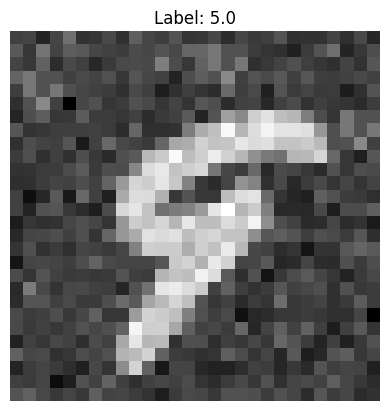

In [7]:
idx = np.random.randint(0, len(X_train))
plt.imshow(X_train[idx].squeeze(), cmap='gray')
plt.title(f'Label: {y_train[idx]}')
plt.axis('off');plt.show()

### Model which I got highest accuracy, but the total parameter is soo high

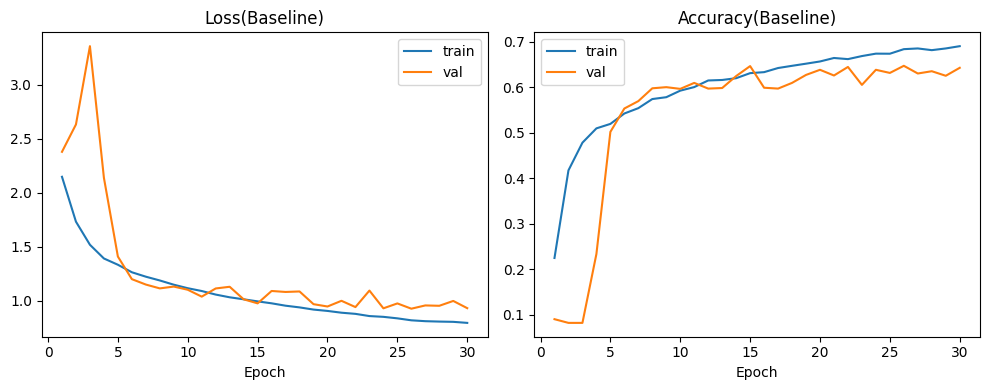

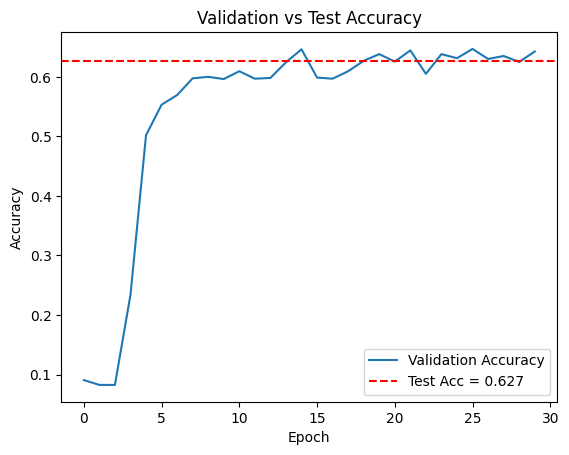

Final accuracy for the model is: 6265
Total parameters in the model are: 148650
Prize for the model before subtracting parameters is: 965000
Final prize for the model is: 816350
Model saved as Highest_accuraccy_model.keras
Model successfully loaded
Model Architecture Diagram: 


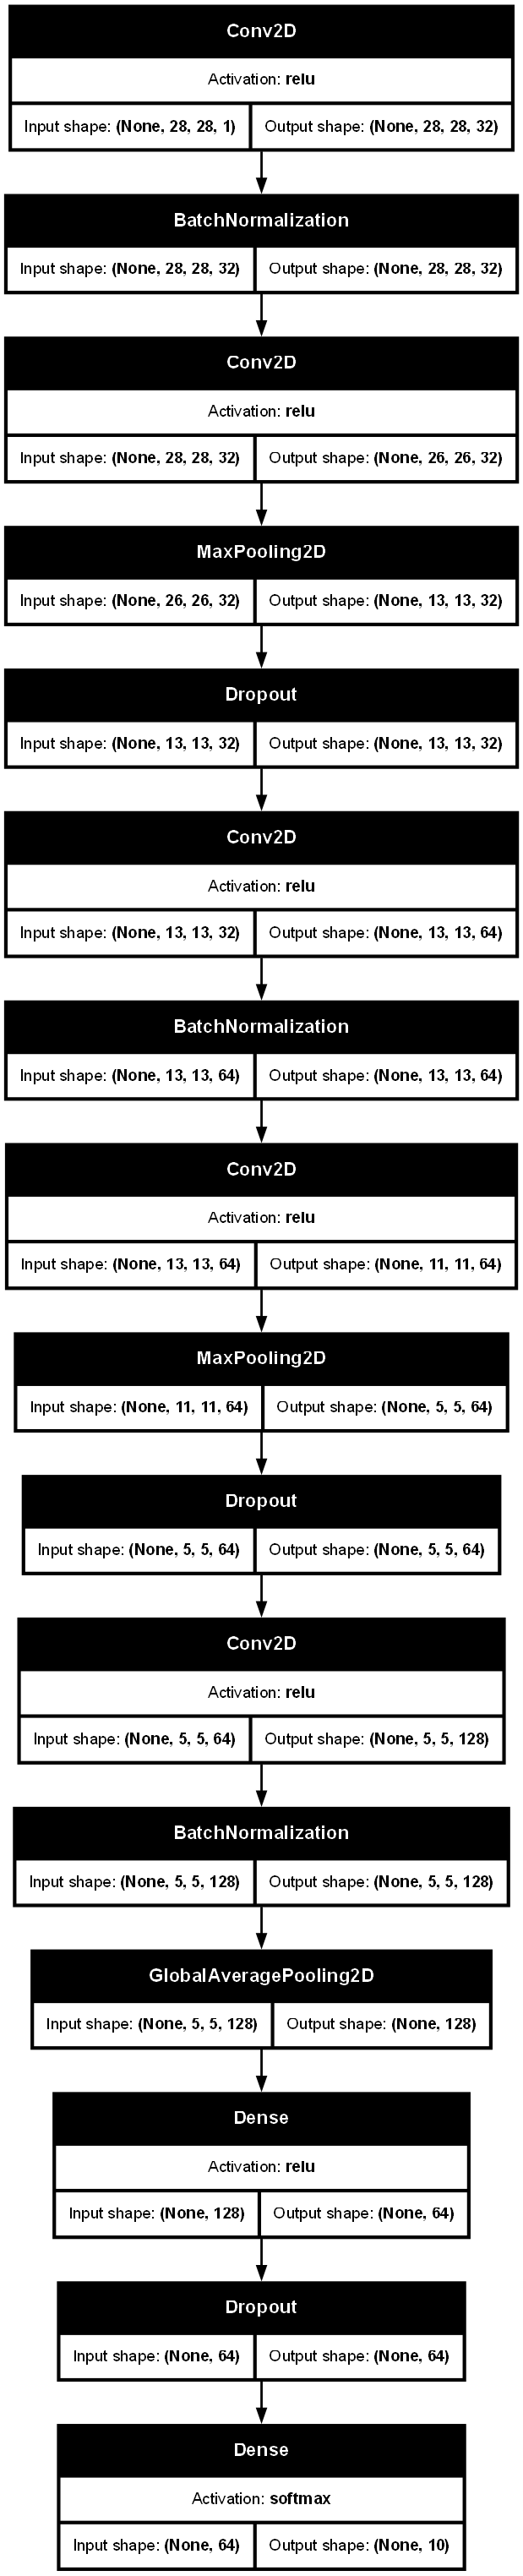

In [8]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

history = model.fit(X_train, y_train, epochs= 30, validation_data=(X_val, y_val), batch_size=64, verbose=0)

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()

Networth(model, test_acc) # Calculate and print the net worth based on the model and test accuracy

current_name = "Highest_accuraccy_model" # Define a name for the model to be saved since this notebook has multiple models.
save_path = save(model, current_name) # Save the model and get the save path
load(save_path, current_name) # Load the model and display its architecture diagram

### Model which I got half size of the parameters from previous model while still keeping decent amount of accuracy.

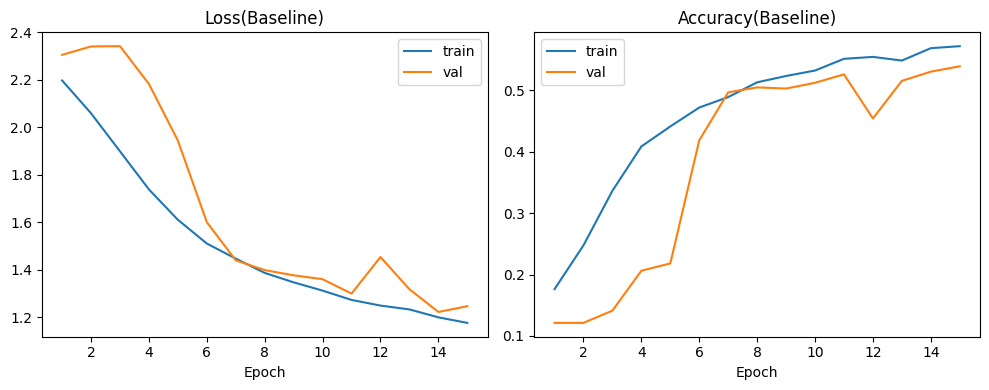

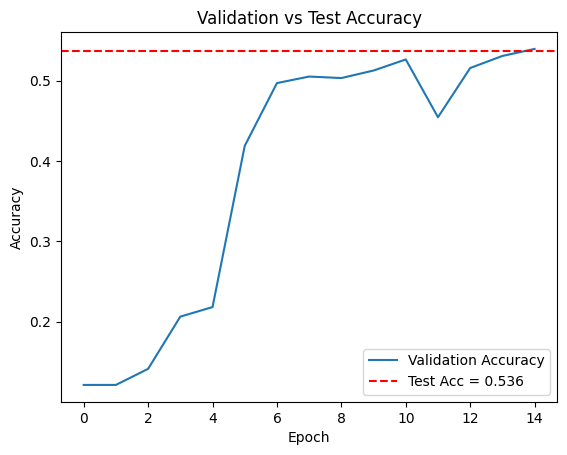

Final accuracy for the model is: 5364
Total parameters in the model are: 56106
Prize for the model before subtracting parameters is: 572800
Final prize for the model is: 516694


In [9]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

history = model.fit(X_train, y_train, epochs= 15, validation_data=(X_val, y_val), batch_size=64, verbose=0)

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()

Networth(model, test_acc) # Calculate and print the net worth based on the model and test accuracy

# current_name = "optimized_model" # Define a name for the model to be saved since this notebook has multiple models.
# save_path = save(model, current_name) # Save the model and get the save path
# load(save_path, current_name) # Load the model and display its architecture diagram

# Commented out saving and loading of the model since it is annoying to scroll through this many layers diagram 
# and they are same as the first model just with less parameters, and we already have the diagram for the first model.

### Pretty low total parameters but cost of accuracy is too high.

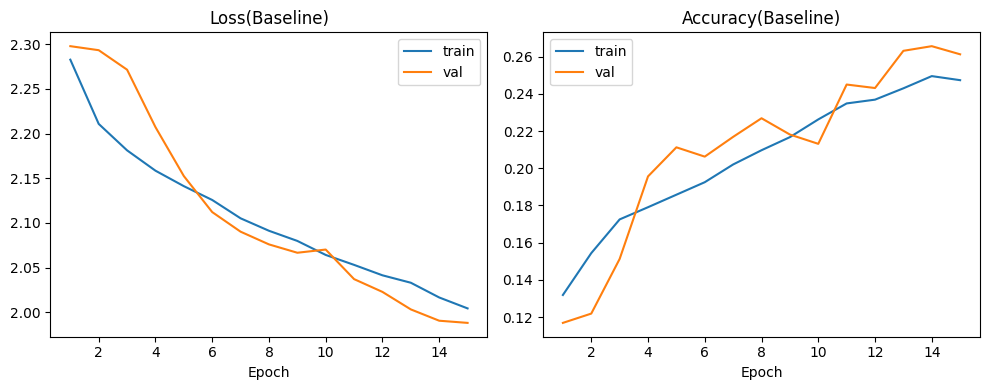

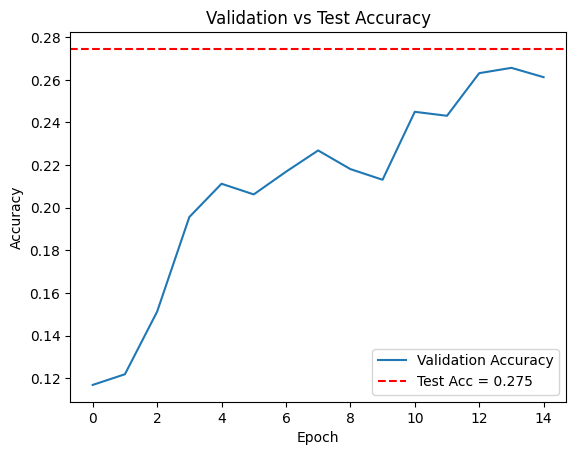

Final accuracy for the model is: 2745
Total parameters in the model are: 12458
Prize for the model before subtracting parameters is: 274500
Final prize for the model is: 262042


In [10]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

history = model.fit(X_train, y_train, epochs=15, validation_data=(X_val, y_val), batch_size=64, verbose=0) # Increased epochs to 30 for better training

print()
def plot_curves(history, title_suffix=''):
    loss, val_loss = history.history['loss'], history.history['val_loss']
    acc,  val_acc  = history.history['accuracy'], history.history['val_accuracy']
    epochs = range(1, len(loss)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, label='train'); plt.plot(epochs, val_loss, label='val')
    plt.title(f'Loss{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, label='train'); plt.plot(epochs, val_acc, label='val')
    plt.title(f'Accuracy{title_suffix}'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.show()

plot_curves(history, '(Baseline)')

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
val_acc = history.history['val_accuracy']
plt.plot(val_acc, label='Validation Accuracy')
plt.axhline(test_acc, color='r', linestyle='--', label=f'Test Acc = {test_acc:.3f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation vs Test Accuracy')
plt.legend(); plt.show()

Networth(model, test_acc) # Calculate and print the net worth based on the model and test accuracy

# current_name = "Lowest_param_model" # Define a name for the model to be saved since this notebook has multiple models.
# save_path = save(model, current_name) # Save the model and get the save path
# load(save_path, current_name) # Load the model and display its architecture diagram

# Commented out saving and loading of the second model since it is annoying to scroll through this many layers diagram 
# and they are same as the first model just with less parameters, and we already have the diagram for the first model.
